# 00 — Dataset Exploration

Anime Sketch Colorization Pair (Kaggle, ~17,769 images).

- Inspect raw 1024x512 side-by-side format (**left = color target, right = sketch**)
- Verify the sketch/color split done by `AnimeColorizationDataset`
- Check image statistics, train/val/test split sizes
- Visualize sample pairs (paired and unpaired mode)

Split mapping: Kaggle `train/` → train; Kaggle `val/` sorted by filename, first half → val, second half → test.

In [32]:
import sys
sys.path.append("..")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

from src.data import AnimeColorizationDataset
from src.utils import seed_everything

seed_everything(42)

DATA_ROOT = Path("../data/anime_colorization")

## 1. Raw file format

One raw file straight from disk: a single 1024×512 RGB image holding both halves side by side.

raw size (W, H): (1024, 512) | mode: RGB


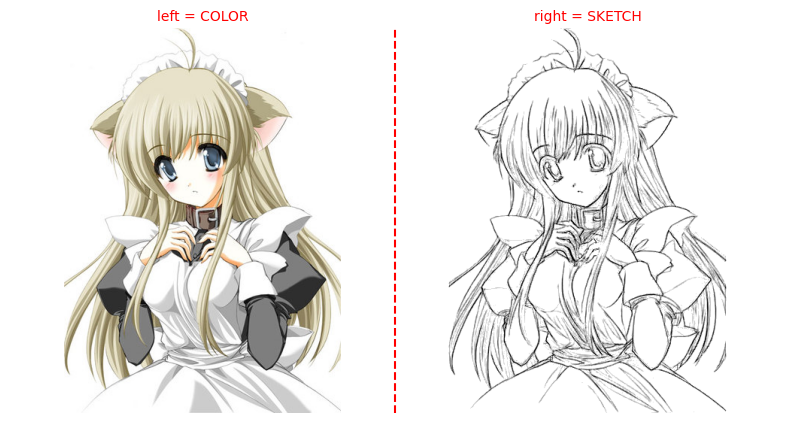

In [33]:
raw_files = sorted((DATA_ROOT / "train").glob("*.png"))

raw = Image.open(raw_files[1]).convert("RGB")
print("raw size (W, H):", raw.size, "| mode:", raw.mode)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(raw)
ax.axvline(raw.size[0] // 2, color="red", linestyle="--")
ax.text(0.25, 1.02, "left = COLOR", transform=ax.transAxes, ha="center", color="red")
ax.text(0.75, 1.02, "right = SKETCH", transform=ax.transAxes, ha="center", color="red")
ax.axis("off")
plt.show()

The chroma score (mean absolute deviation across RGB channels) is ~0 for grayscale content. The right half is consistently grayscale → **right = sketch, left = color**.

In [34]:
def chroma(x: np.ndarray) -> float:
    """Mean absolute deviation across RGB channels (~0 for grayscale)."""
    return float(np.abs(x - x.mean(axis=2, keepdims=True)).mean())

for path in raw_files[:5]:
    im = np.asarray(Image.open(path).convert("RGB"), dtype=np.float32)
    half = im.shape[1] // 2
    print(f"{path.name}: left chroma = {chroma(im[:, :half]):6.2f} | "
          f"right chroma = {chroma(im[:, half:]):6.2f}")

1000000.png: left chroma =  27.02 | right chroma =   0.00
10001.png: left chroma =   3.36 | right chroma =   0.00
10007.png: left chroma =   8.99 | right chroma =   0.00
10010.png: left chroma =   4.78 | right chroma =   0.00
1001122.png: left chroma =   7.35 | right chroma =   0.00


## 2. Splits and tensor format

`AnimeColorizationDataset` returns `{"sketch": Tensor[3,256,256], "color": Tensor[3,256,256]}` normalized to [-1, 1].

In [35]:
datasets = {split: AnimeColorizationDataset(DATA_ROOT, split=split)
            for split in ("train", "val", "test")}
total = sum(len(ds) for ds in datasets.values())
for split, ds in datasets.items():
    print(f"{split:5s}: {len(ds):6d} images ({len(ds) / total:.1%})")

sample = datasets["train"][0]
print("\nsketch:", tuple(sample["sketch"].shape), sample["sketch"].dtype)
print("color :", tuple(sample["color"].shape), sample["color"].dtype)
print(f"value range: [{sample['sketch'].min():.3f}, {sample['sketch'].max():.3f}]")

val_files = {f.name for f in datasets["val"].files}
test_files = {f.name for f in datasets["test"].files}
print("val/test overlap:", len(val_files & test_files))

train:  14224 images (80.0%)
val  :   1772 images (10.0%)
test :   1773 images (10.0%)

sketch: (3, 256, 256) torch.float32
color : (3, 256, 256) torch.float32
value range: [-0.600, 1.000]
val/test overlap: 0


## 2. Sample pairs (paired mode)

Random train samples as returned by the dataset: top row sketch, bottom row the aligned color target.

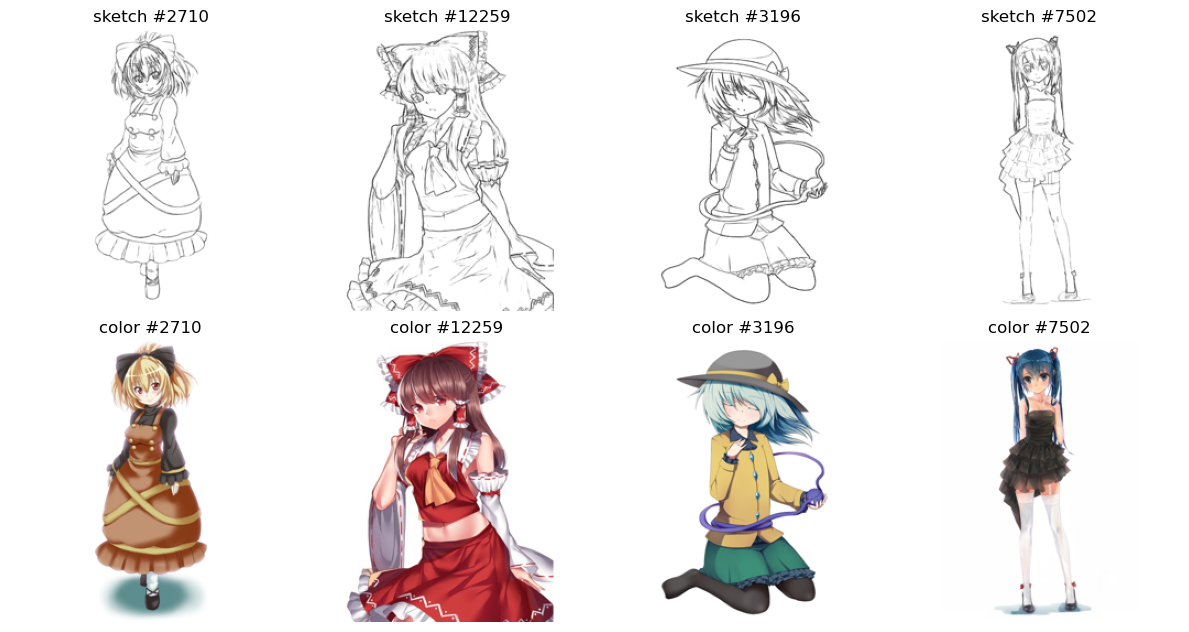

In [36]:
def denorm(t: torch.Tensor) -> np.ndarray:
    """[-1, 1] CHW tensor -> [0, 1] HWC array for imshow."""
    return (t.permute(1, 2, 0).numpy() + 1) / 2

n = 4
indices = torch.randint(len(datasets["train"]), (n,))
fig, axes = plt.subplots(2, n, figsize=(3 * n, 6.5))
for col, idx in enumerate(indices):
    sample = datasets["train"][int(idx)]
    axes[0, col].imshow(denorm(sample["sketch"]))
    axes[0, col].set_title(f"sketch #{int(idx)}")
    axes[1, col].imshow(denorm(sample["color"]))
    axes[1, col].set_title(f"color #{int(idx)}")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Unpaired mode (CycleGAN setting)

With `paired=False` the color target at index `i` comes from a fixed seeded permutation of the indices, so sketches and colors are decoupled.


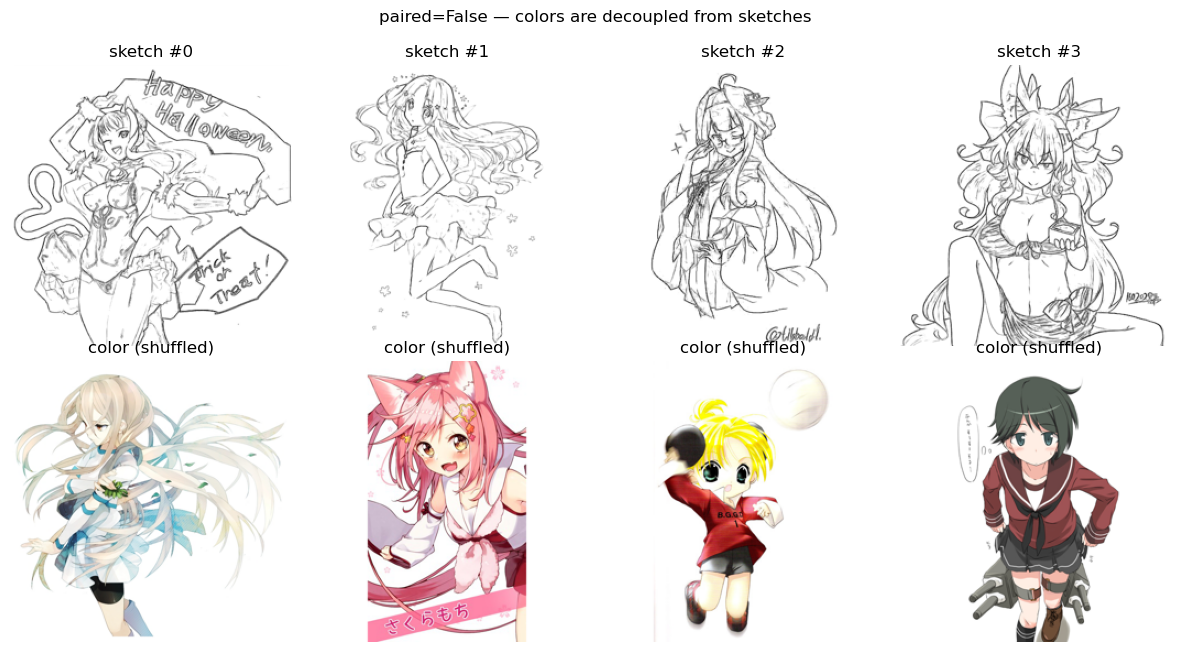

In [37]:
unpaired = AnimeColorizationDataset(DATA_ROOT, split="train", paired=False)

n = 4
idxs = [8935, 1424, 9674, 6912]

fig, axes = plt.subplots(2, n, figsize=(3 * n, 6.5))
for col in range(n):
    idx = idxs[col]
    sample = unpaired[idx]

    axes[0, col].imshow(denorm(sample["sketch"]))
    axes[0, col].set_title(f"sketch #{col}")
    axes[1, col].imshow(denorm(sample["color"]))
    axes[1, col].set_title(f"color (shuffled)")
for ax in axes.ravel():
    ax.axis("off")
plt.suptitle("paired=False — colors are decoupled from sketches", y=1.0)
plt.tight_layout()
plt.show()

## 4. Channel statistics

Per-channel mean/std over a 512-image subsample of the train split (values in the normalized [-1, 1] space). Sketches are bright and near-binary (mostly white background with dark lines), so expect a mean close to 1 and a strongly bimodal histogram.

sketch mean(RGB) = ['0.906', '0.906', '0.906'] | std(RGB) = ['0.260', '0.260', '0.260']
color  mean(RGB) = ['0.759', '0.701', '0.685'] | std(RGB) = ['0.472', '0.520', '0.527']


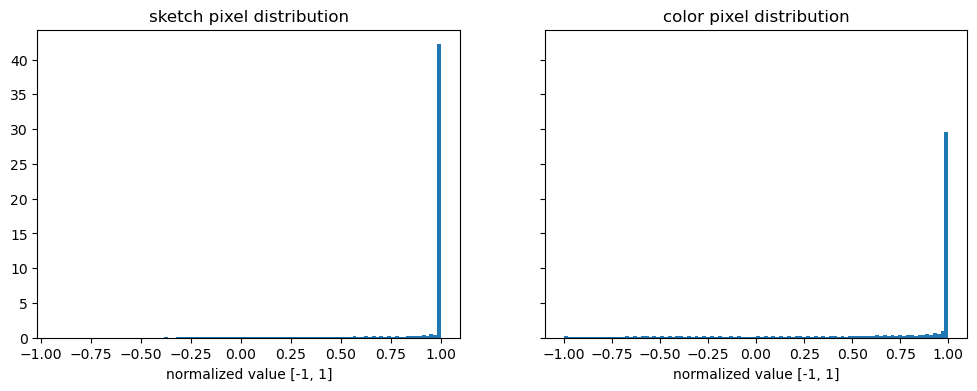

In [38]:
n_stat = 512
subset = torch.utils.data.Subset(datasets["train"], range(n_stat))
loader = torch.utils.data.DataLoader(subset, batch_size=64, num_workers=4)

sums = {k: torch.zeros(3) for k in ("sketch", "color")}
sq_sums = {k: torch.zeros(3) for k in ("sketch", "color")}
hist_samples = {k: [] for k in ("sketch", "color")}
n_pixels = 0
for batch in loader:
    for key in ("sketch", "color"):
        px = batch[key].permute(1, 0, 2, 3).reshape(3, -1)
        sums[key] += px.sum(dim=1)
        sq_sums[key] += (px ** 2).sum(dim=1)
        hist_samples[key].append(px[:, ::257].flatten())
    n_pixels += batch["sketch"][:, 0].numel()

for key in ("sketch", "color"):
    mean = sums[key] / n_pixels
    std = (sq_sums[key] / n_pixels - mean ** 2).sqrt()
    print(f"{key:6s} mean(RGB) = {[f'{v:.3f}' for v in mean]} | "
          f"std(RGB) = {[f'{v:.3f}' for v in std]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, key in zip(axes, ("sketch", "color")):
    ax.hist(torch.cat(hist_samples[key]).numpy(), bins=100, density=True)
    ax.set_title(f"{key} pixel distribution")
    ax.set_xlabel("normalized value [-1, 1]")
plt.show()